In [ ]:
%pip install -q --no-cache-dir "tensorflow-datasets==4.9.9" "protobuf==6.31.1" "importlib-resources>=6.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 356.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [ ]:
import os
import warnings

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
warnings.filterwarnings("ignore", message="Protobuf gencode version.*")

import re
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import google.protobuf
import tensorflow as tf
import tensorflow_datasets as tfds
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

torch.manual_seed(42)
print("Protobuf:", google.protobuf.__version__)
print("TensorFlow:", tf.__version__)
print("TFDS load available:", hasattr(tfds, "load"))
print("PyTorch:", torch.__version__)


Protobuf: 6.31.1
TensorFlow: 2.20.0
TFDS load available: True
PyTorch: 2.11.0+cu128


In [ ]:
PAPER_CONFIG = {
    "char_embedding_dim": 16,
    "cnn_filters": [(1, 32), (2, 32), (3, 64), (4, 128),
                    (5, 256), (6, 512), (7, 1024)],
    "max_word_length": 50,
    "number_of_highway_layers": 2,
    "lstm_hidden_dim": 4096,
    "lstm_projection_dim": 512,
    "number_of_lstm_layers": 2,
    "dropout": 0.1,
    "batch_size": 128,
    "unroll_steps": 20,
    "epochs": 50,
    "learning_rate": 0.2,
    "gradient_clip": 10.0,
    "negative_samples": 8192,
}

PAPER_CONFIG


{'char_embedding_dim': 16,
 'cnn_filters': [(1, 32),
  (2, 32),
  (3, 64),
  (4, 128),
  (5, 256),
  (6, 512),
  (7, 1024)],
 'max_word_length': 50,
 'number_of_highway_layers': 2,
 'lstm_hidden_dim': 4096,
 'lstm_projection_dim': 512,
 'number_of_lstm_layers': 2,
 'dropout': 0.1,
 'batch_size': 128,
 'unroll_steps': 20,
 'epochs': 50,
 'learning_rate': 0.2,
 'gradient_clip': 10.0,
 'negative_samples': 8192}

In [ ]:
MAX_TRAIN_SENTENCES = 100_000
MAX_VALIDATION_SENTENCES = 10_000


def load_lm1b_text(split, limit):
    lm1b = tfds.load(
        "lm1b",
        split=split,
        shuffle_files=(split == "train"),
    )

    texts = []
    for row_number, row in enumerate(tfds.as_numpy(lm1b)):
        if limit is not None and row_number >= limit:
            break

        sentence = row["text"]
        if isinstance(sentence, bytes):
            sentence = sentence.decode("utf-8")
        sentence = sentence.strip()
        if sentence:
            texts.append(sentence)

    return texts


def make_sequences(texts, unroll_steps):
    content_length = unroll_steps - 2
    sequences = []

    for text in texts:
        words = [word.lower() for word in re.findall(r"\b\w+\b", text)]
        for start in range(0, len(words), content_length):
            chunk = words[start:start + content_length]
            if chunk:
                sequences.append(["<bos>"] + chunk + ["<eos>"])

    return sequences


train_texts = load_lm1b_text("train", MAX_TRAIN_SENTENCES)
validation_texts = load_lm1b_text("test", MAX_VALIDATION_SENTENCES)

train_sentences = make_sequences(train_texts, PAPER_CONFIG["unroll_steps"])
validation_sentences = make_sequences(validation_texts, PAPER_CONFIG["unroll_steps"])

if not train_sentences or not validation_sentences:
    raise RuntimeError("LM1B produced an empty training or validation sequence list.")

print("Training sequences:", len(train_sentences))
print("Validation sequences:", len(validation_sentences))
print("Example:", train_sentences[0])


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/lm1b/incomplete.052PW2_1.1.0/lm1b-train.tfrecord*...:   0%|          | 0/3…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/lm1b/incomplete.052PW2_1.1.0/lm1b-test.tfrecord*...:   0%|          | 0/30…

Dataset lm1b downloaded and prepared to /root/tensorflow_datasets/lm1b/1.1.0. Subsequent calls will reuse this data.
Training sequences: 173690
Validation sequences: 17325
Example: ['<bos>', 'their', 'makeshift', 'camps', 'that', 'were', 'set', 'up', 'in', 'bangkok', 's', 'historic', 'district', 'march', '12', 'have', 'spread', 'to', 'the', '<eos>']


In [ ]:
special_words = ["<pad>", "<unk>", "<bos>", "<eos>"]
word_counts = Counter(word for sentence in train_sentences for word in sentence)

max_normal_words = 800_000 - len(special_words)
normal_words = [
    word for word, _ in word_counts.most_common()
    if word not in special_words
][:max_normal_words]

word2id = {word: index for index, word in enumerate(special_words + normal_words)}
id2word = {index: word for word, index in word2id.items()}

special_chars = ["<pad>", "<unk>", "<bow>", "<eow>", "<bos>", "<eos>"]
characters = sorted({
    char
    for sentence in train_sentences
    for word in sentence
    if word not in {"<bos>", "<eos>"}
    for char in word
})

char2id = {token: index for index, token in enumerate(special_chars + characters)}
id2char = {index: token for token, index in char2id.items()}

print("Word vocabulary:", len(word2id))
print("Character vocabulary:", len(char2id))


Word vocabulary: 74022
Character vocabulary: 73


In [ ]:
max_word_length = PAPER_CONFIG["max_word_length"]
max_sentence_length = PAPER_CONFIG["unroll_steps"]


def word_to_char_ids(word):
    if word in {"<bos>", "<eos>"}:
        units = [word]
    else:
        units = ["<bow>"] + list(word) + ["<eow>"]

    ids = [char2id.get(unit, char2id["<unk>"]) for unit in units]
    ids = ids[:max_word_length]
    ids += [char2id["<pad>"]] * (max_word_length - len(ids))
    return ids


class ELMoLanguageModelDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sentence = self.sequences[index]
        length = len(sentence)
        padding_words = max_sentence_length - length

        word_ids = [word2id.get(word, word2id["<unk>"]) for word in sentence]
        word_ids += [word2id["<pad>"]] * padding_words

        char_ids = [word_to_char_ids(word) for word in sentence]
        padded_word = [char2id["<pad>"]] * max_word_length
        char_ids += [padded_word] * padding_words

        return (
            torch.tensor(char_ids, dtype=torch.long),
            torch.tensor(word_ids, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
        )


train_dataset = ELMoLanguageModelDataset(train_sentences)
validation_dataset = ELMoLanguageModelDataset(validation_sentences)

example_chars, example_words, example_length = train_dataset[0]
print("One character example:", example_chars.shape)
print("One word-ID example:", example_words.shape)
print("Valid length:", example_length.item())


One character example: torch.Size([20, 50])
One word-ID example: torch.Size([20])
Valid length: 20


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=PAPER_CONFIG["batch_size"],
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=PAPER_CONFIG["batch_size"],
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

print("Training sequences:", len(train_dataset))
print("Validation sequences:", len(validation_dataset))


Training sequences: 173690
Validation sequences: 17325


In [ ]:
class HighwayLayer(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.transform = nn.Linear(dimension, dimension)
        self.gate = nn.Linear(dimension, dimension)
        nn.init.constant_(self.gate.bias, -2.0)

    def forward(self, x):
        transformed = torch.relu(self.transform(x))
        gate = torch.sigmoid(self.gate(x))
        return gate * transformed + (1.0 - gate) * x


class PaperELMo(nn.Module):
    def __init__(
        self, char_vocab_size, char_padding_idx, word_vocab_size, config,
        include_lm_head=True,
    ):
        super().__init__()

        char_dim = config["char_embedding_dim"]
        projection_dim = config["lstm_projection_dim"]
        hidden_dim = config["lstm_hidden_dim"]
        filters = config["cnn_filters"]

        self.char_embedding = nn.Embedding(
            char_vocab_size, char_dim, padding_idx=char_padding_idx
        )
        nn.init.uniform_(self.char_embedding.weight, -1.0, 1.0)
        with torch.no_grad():
            self.char_embedding.weight[char_padding_idx].zero_()

        self.char_cnns = nn.ModuleList([
            nn.Conv1d(char_dim, number_of_filters, kernel_size=width)
            for width, number_of_filters in filters
        ])

        for convolution in self.char_cnns:
            nn.init.uniform_(convolution.weight, -0.05, 0.05)
            nn.init.zeros_(convolution.bias)

        cnn_output_dim = sum(number for _, number in filters)  # 2048

        self.highway_layers = nn.ModuleList([
            HighwayLayer(cnn_output_dim)
            for _ in range(config["number_of_highway_layers"])
        ])

        self.cnn_projection = nn.Linear(cnn_output_dim, projection_dim)
        nn.init.normal_(self.cnn_projection.weight, 0.0, math.sqrt(1.0 / cnn_output_dim))
        nn.init.zeros_(self.cnn_projection.bias)

        self.dropout = nn.Dropout(config["dropout"])

        self.forward_lstm_1 = nn.LSTM(
            projection_dim, hidden_dim, proj_size=projection_dim, batch_first=True
        )
        self.forward_lstm_2 = nn.LSTM(
            projection_dim, hidden_dim, proj_size=projection_dim, batch_first=True
        )
        self.backward_lstm_1 = nn.LSTM(
            projection_dim, hidden_dim, proj_size=projection_dim, batch_first=True
        )
        self.backward_lstm_2 = nn.LSTM(
            projection_dim, hidden_dim, proj_size=projection_dim, batch_first=True
        )

        self.lm_head = (
            nn.Linear(projection_dim, word_vocab_size)
            if include_lm_head else None
        )

    @staticmethod
    def reverse_valid_words(x, lengths):
        reversed_x = x.clone()
        for index, length in enumerate(lengths.detach().cpu().tolist()):
            reversed_x[index, :length] = torch.flip(x[index, :length], dims=[0])
        return reversed_x

    def forward(self, char_ids, lengths):
        batch_size, sentence_length, max_word_length = char_ids.shape

        flat_ids = char_ids.reshape(batch_size * sentence_length, max_word_length)
        embedded = self.char_embedding(flat_ids).permute(0, 2, 1)

        pooled_features = []
        for convolution in self.char_cnns:
            feature_map = torch.relu(convolution(embedded))
            pooled_features.append(torch.max(feature_map, dim=2).values)

        word_vectors = torch.cat(pooled_features, dim=1)
        for highway in self.highway_layers:
            word_vectors = highway(word_vectors)

        word_vectors = self.cnn_projection(word_vectors)
        word_vectors = word_vectors.reshape(batch_size, sentence_length, -1)

        forward_1, _ = self.forward_lstm_1(self.dropout(word_vectors))
        forward_2_raw, _ = self.forward_lstm_2(self.dropout(forward_1))
        forward_2 = forward_2_raw + forward_1

        reversed_vectors = self.reverse_valid_words(word_vectors, lengths)
        backward_1_reversed, _ = self.backward_lstm_1(self.dropout(reversed_vectors))
        backward_2_raw, _ = self.backward_lstm_2(self.dropout(backward_1_reversed))
        backward_2_reversed = backward_2_raw + backward_1_reversed

        backward_1 = self.reverse_valid_words(backward_1_reversed, lengths)
        backward_2 = self.reverse_valid_words(backward_2_reversed, lengths)

        layer_0 = torch.cat([word_vectors, word_vectors], dim=-1)
        layer_1 = torch.cat([forward_1, backward_1], dim=-1)
        layer_2 = torch.cat([forward_2, backward_2], dim=-1)

        return {
            "word_vectors": word_vectors,
            "layer_0": layer_0,
            "layer_1": layer_1,
            "layer_2": layer_2,
            "contextual_vectors": layer_2,
            "forward_states": self.dropout(forward_2),
            "backward_states": self.dropout(backward_2),
        }


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PaperELMo(
    char_vocab_size=len(char2id),
    char_padding_idx=char2id["<pad>"],
    word_vocab_size=len(word2id),
    config=PAPER_CONFIG,
).to(device)

number_of_parameters = sum(parameter.numel() for parameter in model.parameters())
print("Device:", device)
print(f"Parameters: {number_of_parameters:,}")


Device: cuda
Parameters: 131,636,662


In [ ]:
optimizer = torch.optim.Adagrad(
    model.parameters(),
    lr=PAPER_CONFIG["learning_rate"],
    initial_accumulator_value=1.0,
)

vocabulary_size = len(word2id)
ranks = torch.arange(vocabulary_size, dtype=torch.float64)
sampling_probabilities = (
    torch.log(ranks + 2.0) - torch.log(ranks + 1.0)
) / math.log(vocabulary_size + 1.0)
sampling_probabilities[word2id["<pad>"]] = 0.0
sampling_probabilities /= sampling_probabilities.sum()


def sampled_softmax_loss(hidden_states, targets, valid_mask, output_layer, num_samples):
    hidden_states = hidden_states[valid_mask]
    targets = targets[valid_mask]

    if targets.numel() == 0:
        zero = hidden_states.sum() * 0.0
        return zero, 0, 0

    number_of_classes = output_layer.out_features
    sample_count = min(num_samples, number_of_classes - 1)
    if sample_count < 1:
        raise ValueError("Sampled softmax requires at least two vocabulary entries.")

    probabilities = sampling_probabilities.to(hidden_states.device)
    negative_ids = torch.multinomial(
        probabilities,
        num_samples=sample_count,
        replacement=False,
    )

    true_weights = output_layer.weight[targets]
    true_biases = output_layer.bias[targets]
    true_logits = (hidden_states * true_weights).sum(dim=-1) + true_biases

    negative_weights = output_layer.weight[negative_ids]
    negative_biases = output_layer.bias[negative_ids]
    negative_logits = hidden_states @ negative_weights.T + negative_biases


    true_expected_count = (
        -torch.expm1(sample_count * torch.log1p(-probabilities[targets]))
    ).clamp_min(1e-10)
    negative_expected_count = (
        -torch.expm1(sample_count * torch.log1p(-probabilities[negative_ids]))
    ).clamp_min(1e-10)
    true_logits = true_logits - torch.log(true_expected_count)
    negative_logits = negative_logits - torch.log(negative_expected_count).unsqueeze(0)


    accidental_hits = negative_ids.unsqueeze(0) == targets.unsqueeze(1)
    negative_logits = negative_logits.masked_fill(accidental_hits, float("-inf"))

    sampled_logits = torch.cat([true_logits.unsqueeze(1), negative_logits], dim=1)
    sampled_labels = torch.zeros(targets.size(0), dtype=torch.long, device=targets.device)

    loss_sum = F.cross_entropy(sampled_logits, sampled_labels, reduction="sum")
    correct = (sampled_logits.argmax(dim=1) == 0).sum().item()
    return loss_sum, correct, targets.numel()


In [ ]:
def run_epoch(model, data_loader, training=True):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_predictions = 0

    description = "Training" if training else "Validation"
    progress = tqdm(data_loader, desc=description, leave=False)

    for char_ids, word_ids, lengths in progress:
        char_ids = char_ids.to(device, non_blocking=True)
        word_ids = word_ids.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(char_ids, lengths)

            forward_states = outputs["forward_states"][:, :-1, :]
            forward_targets = word_ids[:, 1:]
            backward_states = outputs["backward_states"][:, 1:, :]
            backward_targets = word_ids[:, :-1]

            forward_mask = forward_targets != word2id["<pad>"]
            backward_mask = backward_targets != word2id["<pad>"]

            forward_loss, forward_correct, forward_count = sampled_softmax_loss(
                forward_states,
                forward_targets,
                forward_mask,
                model.lm_head,
                PAPER_CONFIG["negative_samples"],
            )
            backward_loss, backward_correct, backward_count = sampled_softmax_loss(
                backward_states,
                backward_targets,
                backward_mask,
                model.lm_head,
                PAPER_CONFIG["negative_samples"],
            )

            loss_sum = forward_loss + backward_loss
            prediction_count = forward_count + backward_count
            loss = loss_sum / max(prediction_count, 1)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), PAPER_CONFIG["gradient_clip"]
                )
                optimizer.step()

        total_loss += loss_sum.item()
        total_correct += forward_correct + backward_correct
        total_predictions += prediction_count
        progress.set_postfix(sampled_loss=f"{loss.item():.4f}")

    if total_predictions == 0:
        raise RuntimeError("The data loader produced no valid language-model targets")

    return total_loss / total_predictions, total_correct / total_predictions


In [ ]:
CHECKPOINT_DIR = Path("elmo_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_ENCODER_PATH = CHECKPOINT_DIR / "elmo_best_encoder.pt"


def save_encoder_checkpoint(path, model, epoch, validation_loss):
    encoder_state = {
        name: tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
        if not name.startswith("lm_head.")
    }

    checkpoint = {
        "format_version": 1,
        "epoch": epoch,
        "validation_loss": validation_loss,
        "config": dict(PAPER_CONFIG),
        "char2id": dict(char2id),
        "word2id": dict(word2id),
        "encoder_state_dict": encoder_state,
    }
    torch.save(checkpoint, path)
    print(f"Saved best encoder: {path} ({path.stat().st_size / 1024**2:.1f} MB)")


In [ ]:
epochs = 15
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
best_validation_loss = float("inf")

for epoch in range(1, epochs + 1):
    train_loss, train_accuracy = run_epoch(model, train_loader, training=True)
    val_loss, val_accuracy = run_epoch(model, validation_loader, training=False)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train sampled loss: {train_loss:.4f} | "
        f"Train sampled accuracy: {train_accuracy * 100:.2f}% | "
        f"Val sampled loss: {val_loss:.4f} | "
        f"Val sampled accuracy: {val_accuracy * 100:.2f}%"
    )

    if val_loss < best_validation_loss:
        best_validation_loss = val_loss
        save_encoder_checkpoint(
            BEST_ENCODER_PATH,
            model,
            epoch,
            val_loss,
        )

print("Best validation loss:", best_validation_loss)
print("Benchmark checkpoint:", BEST_ENCODER_PATH.resolve())


Training:   0%|          | 0/1357 [00:00<?, ?it/s]

Validation:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 01/15 | Train sampled loss: 7.3264 | Train sampled accuracy: 8.04% | Val sampled loss: 6.8656 | Val sampled accuracy: 9.67%
Saved best encoder: elmo_checkpoints/elmo_best_encoder.pt (358.8 MB)


Training:   0%|          | 0/1357 [00:00<?, ?it/s]

Validation:   0%|          | 0/136 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 14/15 | Train sampled loss: 5.8453 | Train sampled accuracy: 16.57% | Val sampled loss: 5.9008 | Val sampled accuracy: 16.79%
Saved best encoder: elmo_checkpoints/elmo_best_encoder.pt (358.8 MB)


Training:   0%|          | 0/1357 [00:00<?, ?it/s]

Validation:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 15/15 | Train sampled loss: 5.8040 | Train sampled accuracy: 16.84% | Val sampled loss: 5.8451 | Val sampled accuracy: 17.25%
Saved best encoder: elmo_checkpoints/elmo_best_encoder.pt (358.8 MB)
Best validation loss: 5.8450680025881905
Benchmark checkpoint: /content/elmo_checkpoints/elmo_best_encoder.pt


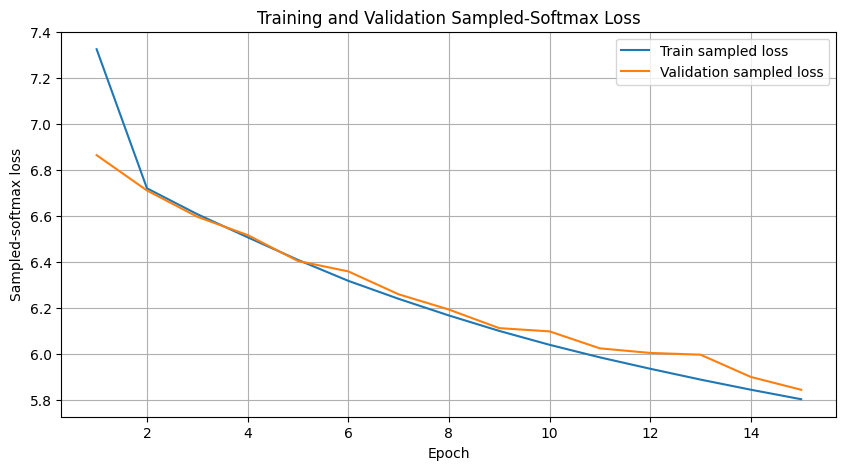

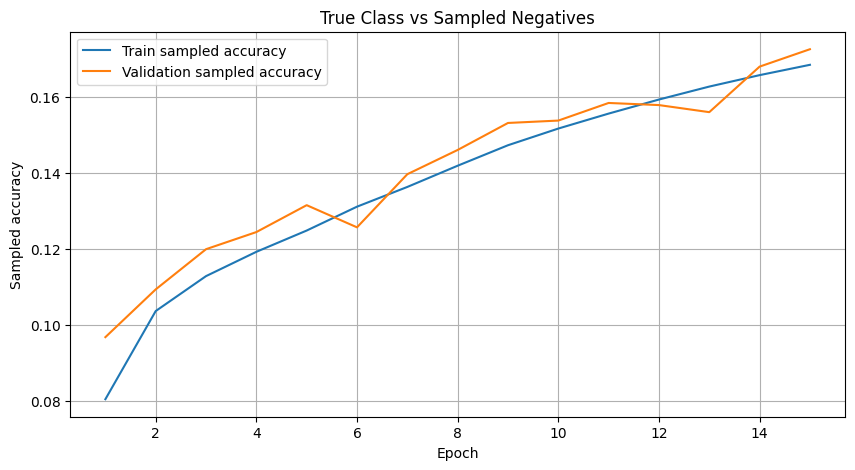

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train sampled loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation sampled loss")
plt.xlabel("Epoch")
plt.ylabel("Sampled-softmax loss")
plt.title("Training and Validation Sampled-Softmax Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracies, label="Train sampled accuracy")
plt.plot(range(1, epochs + 1), val_accuracies, label="Validation sampled accuracy")
plt.xlabel("Epoch")
plt.ylabel("Sampled accuracy")
plt.title("True Class vs Sampled Negatives")
plt.legend()
plt.grid(True)
plt.show()
